Dataset shape after NaN removal: (204080, 31)
Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7271 - val_loss: 0.3433
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3341 - val_loss: 0.2114
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1992 - val_loss: 0.1522
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1428 - val_loss: 0.1200
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1184 - val_loss: 0.1043
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1201 - val_loss: 0.0895
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0872 - val_loss: 0.0867
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0918 - val_loss: 0.0769
Epoch 9/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0813 - val_loss: 0.0735
Epoch 10/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0794 - val_loss: 0.0694
Epoch 11/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0693 - val_loss: 0.0715
Epoch 

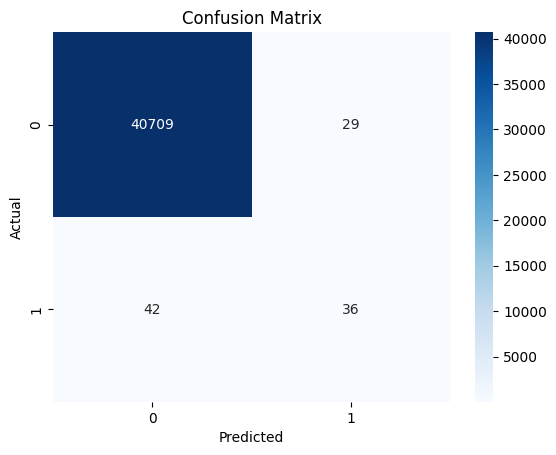


Model saved successfully:
 - fraud_autoencoder.keras
 - fraud_metadata.pkl


In [ ]:
# ============================================================
# AI-POWERED FRAUD DETECTION USING AUTOENCODER
# Trains model and saves artifacts for Streamlit deployment
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# AUTOENCODER FRAUD DETECTOR
# ============================================================

class AutoencoderFraudDetector:
    def __init__(self):
        self.scaler = StandardScaler()
        self.autoencoder = None
        self.optimal_threshold = None

    def build_model(self, input_dim):
        inputs = Input(shape=(input_dim,))
        x = Dense(64, activation="relu")(inputs)
        x = Dense(32, activation="relu")(x)
        latent = Dense(16, activation="tanh")(x)
        x = Dense(32, activation="relu")(latent)
        x = Dense(64, activation="relu")(x)
        outputs = Dense(input_dim, activation="linear")(x)

        model = Model(inputs, outputs)
        model.compile(optimizer="adam", loss="mse")
        return model

    def fit(self, X, y):
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, stratify=y, random_state=42
        )

        X_val, X_thresh, y_val, y_thresh = train_test_split(
            X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
        )

        X_train = self.scaler.fit_transform(X_train)
        X_val = self.scaler.transform(X_val)
        X_thresh = self.scaler.transform(X_thresh)

        X_train_normal = X_train[y_train == 0]
        X_val_normal = X_val[y_val == 0]

        self.autoencoder = self.build_model(X_train.shape[1])
        self.autoencoder.fit(
            X_train_normal, X_train_normal,
            validation_data=(X_val_normal, X_val_normal),
            epochs=50,
            batch_size=256,
            shuffle=True,
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
            verbose=1
        )

        thresh_scores = self.anomaly_scores(X_thresh)
        precisions, recalls, thresholds = precision_recall_curve(
            y_thresh, thresh_scores
        )

        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        f1_scores = f1_scores[:-1]

        self.optimal_threshold = thresholds[np.argmax(f1_scores)]
        print(f"\nOptimal threshold: {self.optimal_threshold:.6f}")

    def anomaly_scores(self, X):
        recon = self.autoencoder.predict(X, verbose=0)
        return np.mean(np.square(X - recon), axis=1)

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        scores = self.anomaly_scores(X_scaled)
        preds = (scores >= self.optimal_threshold).astype(int)
        return preds, scores


# ============================================================
# MAIN EXECUTION
# ============================================================

def main():
    # Load dataset
    df = pd.read_csv("creditcard.csv")

    # ================= FIX FOR NaN ERROR =================
    df = df.dropna(subset=["Class"])
    # =====================================================

    print("Dataset shape after NaN removal:", df.shape)

    X = df.drop("Class", axis=1)
    y = df["Class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train model
    detector = AutoencoderFraudDetector()
    detector.fit(X_train, y_train)

    # Test performance
    y_pred, scores = detector.predict(X_test)

    scaler = MinMaxScaler()
    train_scores = detector.anomaly_scores(
        detector.scaler.transform(X_train)
    )
    scaler.fit(train_scores.reshape(-1, 1))
    y_proba = scaler.transform(scores.reshape(-1, 1))

    print("\n=== MODEL PERFORMANCE ===")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    # ================= SAVE ARTIFACTS =================
    detector.autoencoder.save("fraud_autoencoder.keras")

    with open("fraud_metadata.pkl", "wb") as f:
        pickle.dump(
            {
                "scaler": detector.scaler,
                "threshold": detector.optimal_threshold
            },
            f
        )

    print("\nModel saved successfully:")
    print(" - fraud_autoencoder.keras")
    print(" - fraud_metadata.pkl")


if __name__ == "__main__":
    main()


In [ ]:
#### synthetic data genatrator for testing

import pandas as pd
import numpy as np

# Simple data generation
np.random.seed(42)

# Create 10,000 rows
data = []
for i in range(10000):
    row = {
        'Time': float(i * 0.5 + np.random.normal(0, 0.1)),
    }

    # Add V1-V28
    for j in range(1, 29):
        row[f'V{j}'] = np.random.normal(0, 1)

    # Add Amount
    row['Amount'] = max(1, np.random.exponential(100))

    # Add Class (1% fraud)
    row['Class'] = 1 if np.random.random() < 0.01 else 0

    data.append(row)

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('simple_fraud_data.csv', index=False)

print(f"✅ Generated {len(df)} rows")
print(f"📊 Fraud percentage: {df['Class'].mean()*100:.2f}%")
print(f"📁 Saved as 'simple_fraud_data.csv'")
print("\nSample data:")
print(df.head())

✅ Generated 10000 rows
📊 Fraud percentage: 0.72%
📁 Saved as 'simple_fraud_data.csv'

Sample data:
       Time        V1        V2        V3        V4        V5        V6  \
0  0.049671 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1  0.470831 -0.013497 -1.057711  0.822545 -1.220844  0.208864 -1.959670   
2  0.889367 -1.196207  0.812526  1.356240 -0.072010  1.003533  0.361636   
3  1.596864 -0.702053 -0.327662 -0.392108 -1.463515  0.296120  0.261055   
4  2.140279 -1.401851  0.586857  2.190456 -0.990536 -0.566298  0.099651   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.767435 -0.469474  0.542560  ... -0.225776  0.067528 -1.424748 -0.544383   
1 -1.328186  0.196861  0.738467  ... -0.676922  0.611676  1.031000  0.931280   
2 -0.645120  0.361396  1.538037  ... -0.518270 -0.808494 -0.501757  0.915402   
3  0.005113 -0.234587 -1.415371  ...  0.060230  2.463242 -0.192361  0.301547   
4 -0.503476 -1.550663  0.068563  ...  0.184634  0.2